# MeteoSwiss regional reference precipitation — station ensemble around CH-LAE, 2004-2025

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Reference**: every MeteoSwiss precipitation station
within 21 km &nbsp;&nbsp;|&nbsp;&nbsp; **Product**: daily 2004-2025
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

> **Source: MeteoSwiss.** These data are free to use, but the source must be cited whenever they
> are reproduced or redistributed. Keep this attribution with any figure or derived product.

## ℹ️ About this notebook

Downloads **daily** precipitation from the MeteoSwiss open-data STAC API for every station within
`MAX_DIST_KM` of the tower that covers the whole 2004-2025 period, and writes them as one reference
product.

This notebook **does not touch the InfluxDB database** and screens nothing. Like the other
`10_REFERENCE` notebooks it only fetches independent reference data and puts it on our time axis.

::: {.callout-important title="Why an ensemble, when we already have OED"}
`MeteoSwiss_OED_PREC_2004-2025.ipynb` fetches the nearest gauge, Ehrendingen (OED), and that is the
right tool for spotting *when* something changed at the tower: it is close, and it resolves
accumulation faults over weeks.

It cannot answer a different question — **which of two tower records is right**. When the tower and
one reference disagree, a single reference cannot say which of the two moved. The 2018 acquisition
change at CH-LAE (see `30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb`) is exactly that situation: the
tower's catch ratio against OED steps by a factor of 1.3, and OED alone cannot rule out that OED is
what changed.

An ensemble can. If the tower steps against **thirteen** independent stations at once, the tower
moved. And because the stations span a range of elevations, they also give an
elevation-precipitation gradient, which turns "the tower disagrees with its neighbours" into
"the tower is *N* % away from what a station at 690 m should record".

That is the whole purpose of this product. It is a **diagnostic** reference: nothing here is ever
written into a tower series, and no value here is used to fill a gap. (Sub-daily gap-filling uses
the OED 30MIN product, which is a different file.)
:::

## ⏱️ Timestamp convention (important)

MeteoSwiss publishes all reference timestamps in **UTC**, and the **precipitation day runs 06 UTC →
06 UTC**: the value labelled day `D` covers `[D 06:00 UTC, D+1 06:00 UTC)`. This is *not* a
local-midnight day.

Like the OED **daily** product, this file is therefore left on its **native MeteoSwiss
precipitation day** and is **not** shifted to local time. Anything comparing our own data against it
must re-aggregate ours onto the same 06-UTC day first — notebook `30_PRODUCTS/08` does this with a
`to_ms_precip_day()` helper. Comparing against a local-midnight daily sum is wrong by six hours and
smears every rain event across two days.

Only the daily resolution is fetched here. Sub-daily data would be far heavier, most of these
stations do not have it back to 2004, and the questions this product exists to answer — annual
level, elevation gradient, era-to-era steps — are all daily-or-coarser questions.

## ✏️ Settings

In [1]:
# --- Site ---
SITE_LAT = 47.478333   # CH-LAE
SITE_LON = 8.364389    # CH-LAE
SITE_ALT = 690.0       # m a.s.l., tower base

# --- Station selection ---
# 21 km keeps the ensemble inside the same precipitation regime (Swiss Plateau / Jura foothills)
# while still giving a usable elevation range. Widening it pulls in Alpine foothill stations whose
# gradient is different; narrowing it below ~15 km leaves too few stations to average.
MAX_DIST_KM = 21.0
MIN_DAYS = 6000        # a station must cover most of 2004-2025 to be comparable across eras
MIN_STATIONS = 8       # fewer than this and the ensemble is not an ensemble - the notebook raises

STAC_COLLECTIONS = ['ch.meteoschweiz.ogd-smn-precip',  # precipitation-only network
                    'ch.meteoschweiz.ogd-smn']         # full automatic weather stations
PARAM_DAILY = 'rre150d0'  # precipitation sum, daily [mm]

# --- Period ---
START = '2004-01-01'   # included
STOP = '2025-12-31'    # included

# --- Output ---
# Mirrors this notebook's own path under the external data folder, per the repo convention.
OUTDIR = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
          r'\workflow\10_METEO\10_REFERENCE')
OUTNAME = 'PREC_MeteoSwiss_REGIONAL_DAILY'
OUTNAME_STATIONS = 'PREC_MeteoSwiss_REGIONAL_STATIONS'  # metadata for the file above, not a
                                                        # second product: readers need each
                                                        # station's elevation and distance
EXPORT_FORMATS = ('parquet', 'csv')

### Imports

In [2]:
import io
import json
import urllib.request
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', 40)
pd.set_option('display.width', 1000)
print(f"Last run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f'pandas v{pd.__version__}')

Last run: 2026-07-21 13:22:37
pandas v3.0.3


## 🔧 Helpers

`read_meta` fetches a collection's station table, `haversine` gives great-circle distance from the
tower, `stac_assets` resolves one station's files, and `read_ms_csv` reads one MeteoSwiss CSV.

In [3]:
def _fetch(url: str) -> bytes:
    with urllib.request.urlopen(url) as r:
        return r.read()


def read_meta(collection: str) -> pd.DataFrame:
    """Station metadata table for a STAC collection, as published by MeteoSwiss."""
    short = collection.split('.')[-1]
    raw = _fetch(f'https://data.geo.admin.ch/{collection}/{short}_meta_stations.csv')
    for enc in ('utf-8', 'cp1252', 'latin-1'):
        try:
            df = pd.read_csv(io.BytesIO(raw), sep=';', encoding=enc)
            break
        except UnicodeDecodeError:
            continue
    else:
        raise RuntimeError(f'cannot decode the station table of {collection}')
    needed = {'station_abbr', 'station_name', 'station_height_masl'}
    if not needed.issubset(df.columns):
        raise ValueError(f'{collection}: station table is missing {needed - set(df.columns)}')
    df['collection'] = collection
    return df


def haversine_km(lat, lon) -> float:
    """Great-circle distance from CH-LAE, in km."""
    R = 6371.0
    p1, p2 = np.radians(SITE_LAT), np.radians(lat)
    dphi, dlam = p2 - p1, np.radians(lon - SITE_LON)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def stac_assets(collection: str, station: str) -> dict:
    """Return {filename: href} for one station. Raises if the item exposes no assets."""
    url = (f'https://data.geo.admin.ch/api/stac/v1/collections/{collection}'
           f'/items/{station.lower()}')
    assets = {k: v['href'] for k, v in json.loads(_fetch(url)).get('assets', {}).items()}
    if not assets:
        raise ValueError(f'STAC item {url} exposes no assets - wrong collection or station?')
    return assets


def read_ms_csv(href: str, param: str) -> pd.Series:
    """Read one MeteoSwiss CSV and return *param* as a UTC-indexed, sorted Series."""
    df = pd.read_csv(io.BytesIO(_fetch(href)), sep=';')
    if param not in df.columns:
        raise ValueError(f'{param} not in {href} (has: {list(df.columns)[:8]})')
    df['TIMESTAMP'] = pd.to_datetime(df['reference_timestamp'], format='%d.%m.%Y %H:%M')
    return df.set_index('TIMESTAMP')[param].sort_index()

### Negative control

Both network helpers can fail quietly if a station or parameter is wrong — an empty asset map reads
as "no files yet", a missing column as "no data". A silently empty ensemble would be the worst
outcome here, because the whole point of this product is that it averages many stations. Prove they
raise instead.

In [4]:
# A station that does not exist in this collection.
try:
    stac_assets('ch.meteoschweiz.ogd-smn', 'notastation')
except Exception as e:
    print(f'PASSED - unknown station raises: {type(e).__name__}')
else:
    raise AssertionError('(!) FAILED - stac_assets accepted a station that does not exist')

# A parameter that is not in a precipitation file.
_a = stac_assets('ch.meteoschweiz.ogd-smn-precip', 'oed')
_daily_file = next(k for k in _a if '_d_historical' in k)
try:
    read_ms_csv(_a[_daily_file], 'gre000d0')
except ValueError as e:
    print(f'PASSED - unknown parameter raises: {str(e)[:100]}')
else:
    raise AssertionError('(!) FAILED - read_ms_csv accepted a parameter that is not in the file')

PASSED - unknown station raises: HTTPError


PASSED - unknown parameter raises: gre000d0 not in https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn-precip/oed/ogd-smn-precip_oed_d_hi


## 📍 Select the stations

In [5]:
meta = pd.concat([read_meta(c) for c in STAC_COLLECTIONS], ignore_index=True)
LAT = next(c for c in meta.columns if 'wgs84_lat' in c)
LON = next(c for c in meta.columns if 'wgs84_lon' in c)
meta['dist_km'] = haversine_km(meta[LAT].astype(float), meta[LON].astype(float))
near = meta[meta.dist_km <= MAX_DIST_KM].sort_values('dist_km')

print(f'{len(meta)} MeteoSwiss stations in {len(STAC_COLLECTIONS)} collections; '
      f'{len(near)} within {MAX_DIST_KM:.0f} km of CH-LAE')
display(near[['station_abbr', 'station_name', 'station_height_masl', 'dist_km', 'collection']]
        .rename(columns={'station_height_masl': 'alt_m'}).round(2).reset_index(drop=True))

299 MeteoSwiss stations in 2 collections; 16 within 21 km of CH-LAE


,station_abbr,station_name,alt_m,dist_km,collection
0,LAE,Lägern,845.0,2.50,ch.meteoschweiz.ogd-smn
1,OED,Ehrendingen,428.0,3.82,ch.meteoschweiz.ogd-smn-precip
2,DIT,Dietikon,384.0,7.81,ch.meteoschweiz.ogd-smn-precip
3,AGSTE,Stetten,355.0,10.31,ch.meteoschweiz.ogd-smn-precip
4,KAI,"Kaiserstuhl, AG",361.0,10.90,ch.meteoschweiz.ogd-smn-precip
5,PSI,Würenlingen / PSI,334.0,12.18,ch.meteoschweiz.ogd-smn
6,REH,Zürich / Affoltern,444.0,12.85,ch.meteoschweiz.ogd-smn
7,KLO,Zürich / Kloten,426.0,12.89,ch.meteoschweiz.ogd-smn
8,BUE,Bülach,403.0,13.10,ch.meteoschweiz.ogd-smn-precip
9,BEZ,Beznau,326.0,13.19,ch.meteoschweiz.ogd-smn


Not every nearby station is usable. Two of the most interesting — **Lägern (LAE)**, the SMN station
on our own ridge, and **Uetliberg (UEB)**, the other local hilltop — publish no precipitation at
all, which is why the ensemble ends up entirely below the tower's elevation. That is a real
limitation of this reference and is recorded in the notes at the end.

In [6]:
%%time

series, info = {}, []
for _, r in near.iterrows():
    ab, coll = r['station_abbr'], r['collection']
    try:
        assets = stac_assets(coll, ab)
    except Exception as e:
        print(f'  {ab:<6} skipped: STAC lookup failed ({type(e).__name__})')
        continue
    files = sorted(k for k in assets if '_d_historical' in k)
    if not files:
        print(f'  {ab:<6} skipped: no daily historical file')
        continue
    parts = []
    for k in files:
        try:
            parts.append(read_ms_csv(assets[k], PARAM_DAILY))
        except ValueError:
            pass  # this file does not carry daily precipitation
    if not parts:
        print(f'  {ab:<6} skipped: {PARAM_DAILY} absent (station measures no precipitation)')
        continue
    s = pd.concat(parts).sort_index()
    s = s[~s.index.duplicated(keep='first')].loc[START:STOP]
    if int(s.notna().sum()) < MIN_DAYS:
        print(f'  {ab:<6} skipped: only {int(s.notna().sum())} days in {START}-{STOP}')
        continue
    series[ab] = s
    info.append({'station_abbr': ab, 'station_name': r['station_name'],
                 'alt_m': float(r['station_height_masl']), 'dist_km': round(r['dist_km'], 1),
                 'lat': float(r[LAT]), 'lon': float(r[LON]), 'collection': coll,
                 'days': int(s.notna().sum()),
                 'mean_annual_mm': round(float(s.sum()) / (s.notna().sum() / 365.25))})
    print(f'  {ab:<6} OK: {int(s.notna().sum())} days, '
          f'{info[-1]["mean_annual_mm"]:.0f} mm/a, {info[-1]["alt_m"]:.0f} m, '
          f'{info[-1]["dist_km"]:.1f} km')

stations = pd.DataFrame(info).sort_values('dist_km').reset_index(drop=True)
print(f'\n{len(stations)} usable stations')
assert len(stations) >= MIN_STATIONS, (
    f'only {len(stations)} usable stations, need at least {MIN_STATIONS} - an ensemble this small '
    f'is not robust to one bad gauge')
display(stations)

  LAE    skipped: only 0 days in 2004-01-01-2025-12-31
  OED    OK: 8036 days, 1022 mm/a, 428 m, 3.8 km


  DIT    OK: 8036 days, 1042 mm/a, 384 m, 7.8 km


  AGSTE  skipped: only 3862 days in 2004-01-01-2025-12-31


  KAI    OK: 7914 days, 992 mm/a, 361 m, 10.9 km


  PSI    OK: 8023 days, 1000 mm/a, 334 m, 12.2 km


...

  UBB    OK: 8036 days, 1004 mm/a, 536 m, 17.5 km


  SMA    OK: 8036 days, 1079 mm/a, 604 m, 18.7 km


  LEI    OK: 8036 days, 1011 mm/a, 341 m, 18.7 km

13 usable stations


,station_abbr,station_name,alt_m,dist_km,lat,lon,collection,days,mean_annual_mm
0,OED,Ehrendingen,428.0,3.8,47.508125,8.339047,ch.meteoschweiz.ogd-smn-precip,8036,1022
1,DIT,Dietikon,384.0,7.8,47.413558,8.404472,ch.meteoschweiz.ogd-smn-precip,8036,1042
2,KAI,"Kaiserstuhl, AG",361.0,10.9,47.570603,8.413231,ch.meteoschweiz.ogd-smn-precip,7914,992
3,PSI,Würenlingen / PSI,334.0,12.2,47.536475,8.226944,ch.meteoschweiz.ogd-smn,8023,1000
4,REH,Zürich / Affoltern,444.0,12.8,47.427694,8.517953,ch.meteoschweiz.ogd-smn,8036,1001
5,KLO,Zürich / Kloten,426.0,12.9,47.479611,8.535961,ch.meteoschweiz.ogd-smn,8036,992
6,BUE,Bülach,403.0,13.1,47.519594,8.527731,ch.meteoschweiz.ogd-smn-precip,8036,961
7,BEZ,Beznau,326.0,13.2,47.557256,8.233325,ch.meteoschweiz.ogd-smn,8036,945
8,WAG,Waldegg,545.0,14.6,47.362269,8.454789,ch.meteoschweiz.ogd-smn-precip,8036,1111
9,OPF,Opfikon,424.0,15.4,47.437633,8.560339,ch.meteoschweiz.ogd-smn-precip,8036,1096


CPU times: total: 1.14 s
Wall time: 6.52 s


## 📅 Assemble the daily product

In [7]:
# Column names carry the _<station>_MS suffix of every reference product here, plus _DAILY, so a
# column can never be confused with a tower series or with the OED 30MIN column PREC_OED_MS.
daily = pd.DataFrame({f'PREC_{ab}_MS_DAILY': s for ab, s in series.items()})
daily = daily.reindex(pd.date_range(START, STOP, freq='D'))
daily.index.name = 'TIMESTAMP_MS_PRECIP_DAY'
daily = daily[[f'PREC_{ab}_MS_DAILY' for ab in stations.station_abbr]]  # order by distance

print(f'{daily.shape[0]:,} days x {daily.shape[1]} stations, '
      f'{daily.index[0].date()} -> {daily.index[-1].date()}')
print(f'complete days (every station present): {int(daily.notna().all(axis=1).sum()):,} '
      f'({100 * daily.notna().all(axis=1).mean():.1f}%)')
display(daily.head())

8,036 days x 13 stations, 2004-01-01 -> 2025-12-31
complete days (every station present): 7,901 (98.3%)


,PREC_OED_MS_DAILY,PREC_DIT_MS_DAILY,PREC_KAI_MS_DAILY,PREC_PSI_MS_DAILY,PREC_REH_MS_DAILY,PREC_KLO_MS_DAILY,PREC_BUE_MS_DAILY,PREC_BEZ_MS_DAILY,PREC_WAG_MS_DAILY,PREC_OPF_MS_DAILY,PREC_UBB_MS_DAILY,PREC_SMA_MS_DAILY,PREC_LEI_MS_DAILY
TIMESTAMP_MS_PRECIP_DAY,,,,,,,,,,,,,
2004-01-01,5.4,3.9,2.8,0.0,2.8,3.0,3.3,2.8,3.7,3.8,4.0,3.7,3.3
2004-01-02,0.0,0.2,0.4,1.5,0.4,0.4,0.2,0.7,0.3,0.5,0.0,0.4,2.5
2004-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0
2004-01-05,0.0,0.0,0.0,1.6,0.0,0.0,0.1,0.0,0.1,0.3,0.0,0.0,0.0


### Sanity checks

In [8]:
assert daily.index.is_monotonic_increasing, '(!) index not sorted'
assert not daily.index.has_duplicates, '(!) duplicate days'
assert (daily.index.to_series().diff().dropna() == pd.Timedelta('1D')).all(), '(!) index not daily'
assert (daily.stack(future_stack=True).dropna() >= 0).all(), '(!) negative precipitation'
assert daily.notna().all(axis=1).mean() > 0.9, '(!) too few days with a complete ensemble'

# Stations this close must agree strongly on daily totals. A station correlating below ~0.6 with
# the ensemble is either in a different regime or broken, and would poison an average.
_ens = daily.mean(axis=1)
_corr = daily.corrwith(_ens)
display(_corr.round(3).rename('corr with the ensemble mean').to_frame())
assert (_corr > 0.6).all(), f'(!) a station barely correlates with the ensemble: {_corr.idxmin()}'
print('PASSED - daily index, non-negative, complete ensemble, all stations mutually consistent')

,corr with the ensemble mean
PREC_OED_MS_DAILY,0.941
PREC_DIT_MS_DAILY,0.947
PREC_KAI_MS_DAILY,0.915
PREC_PSI_MS_DAILY,0.914
PREC_REH_MS_DAILY,0.947
PREC_KLO_MS_DAILY,0.948
PREC_BUE_MS_DAILY,0.941
PREC_BEZ_MS_DAILY,0.907
PREC_WAG_MS_DAILY,0.917
PREC_OPF_MS_DAILY,0.940


PASSED - daily index, non-negative, complete ensemble, all stations mutually consistent


### Characterising the ensemble

Two properties are what downstream notebooks actually use: the **spread** between stations (how
much of a tower-vs-station disagreement is just normal spatial variability) and the
**elevation gradient** (what a station at the tower's 690 m should record).

In [9]:
_ann = daily.resample('YS').sum(min_count=350)
_mean_annual = _ann.mean()
_alt = stations.set_index('station_abbr')['alt_m']
_alt.index = [f'PREC_{a}_MS_DAILY' for a in _alt.index]
_alt = _alt.reindex(_mean_annual.index)

_slope, _icept = np.polyfit(_alt.values, _mean_annual.values, 1)
_pred = _slope * SITE_ALT + _icept
_resid = _mean_annual.values - (_slope * _alt.values + _icept)
_r = np.corrcoef(_alt.values, _mean_annual.values)[0, 1]

print(f'mean annual total across the ensemble: {_mean_annual.mean():.0f} mm '
      f'(station range {_mean_annual.min():.0f} - {_mean_annual.max():.0f} mm)')
print(f'elevation gradient: {_slope * 100:+.1f} mm per 100 m  (r = {_r:.2f}, '
      f'residual scatter {np.sqrt((_resid ** 2).mean()):.0f} mm)')
print(f'extrapolated to the tower at {SITE_ALT:.0f} m: {_pred:.0f} mm/a')
print(f'\n(!) The tower is ABOVE every station in the ensemble '
      f'({_alt.min():.0f}-{_alt.max():.0f} m), so this is an extrapolation. It is used as an '
      f'order-of-magnitude expectation, not as a calibration target.')

mean annual total across the ensemble: 1019 mm (station range 945 - 1111 mm)
elevation gradient: +35.2 mm per 100 m  (r = 0.61, residual scatter 38 mm)
extrapolated to the tower at 690 m: 1112 mm/a

(!) The tower is ABOVE every station in the ensemble (326-604 m), so this is an extrapolation. It is used as an order-of-magnitude expectation, not as a calibration target.


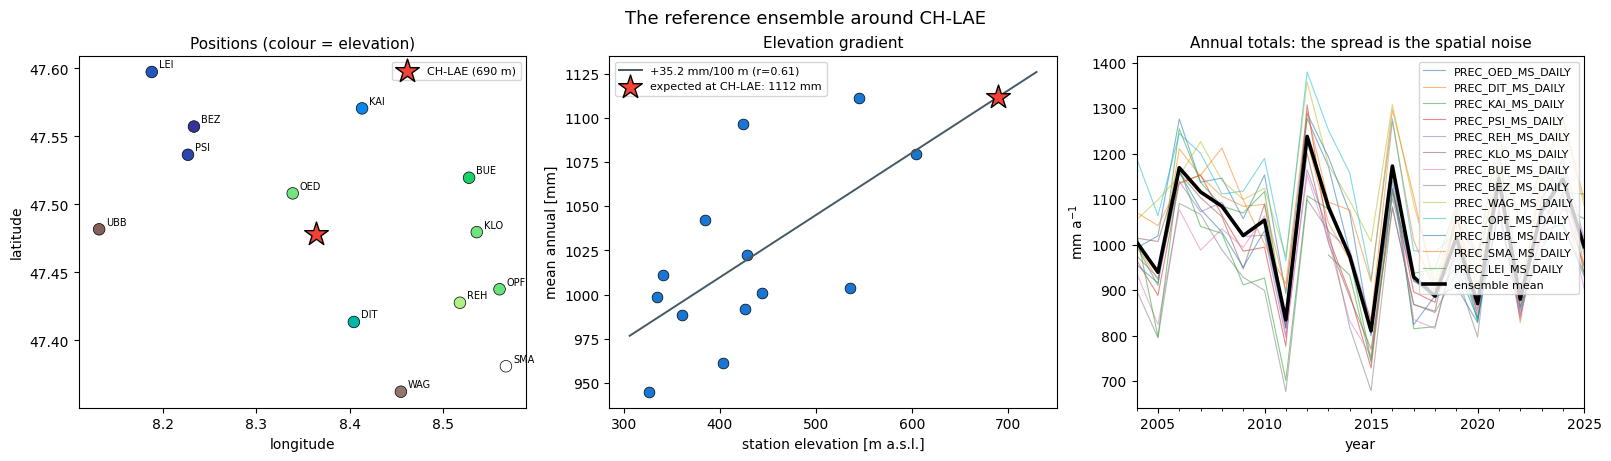

In [10]:
fig, axs = plt.subplots(ncols=3, figsize=(16, 4.5), dpi=100, layout='constrained')
fig.suptitle('The reference ensemble around CH-LAE', fontsize=13)

axs[0].scatter(stations.lon, stations.lat, c=stations.alt_m, cmap='terrain', s=70,
               edgecolor='k', linewidth=.5, zorder=3)
axs[0].scatter([SITE_LON], [SITE_LAT], marker='*', s=320, color='#F44336', edgecolor='k',
               zorder=4, label='CH-LAE (690 m)')
for _, r in stations.iterrows():
    axs[0].annotate(r.station_abbr, (r.lon, r.lat), fontsize=7,
                    textcoords='offset points', xytext=(5, 3))
axs[0].set_xlabel('longitude')
axs[0].set_ylabel('latitude')
axs[0].set_title('Positions (colour = elevation)', fontsize=11)
axs[0].legend(fontsize=8)

axs[1].scatter(_alt.values, _mean_annual.values, s=60, color='#1976D2', edgecolor='k', linewidth=.5)
_xx = np.linspace(_alt.min() - 20, SITE_ALT + 40, 50)
axs[1].plot(_xx, _slope * _xx + _icept, color='#455A64', lw=1.4,
            label=f'{_slope*100:+.1f} mm/100 m (r={_r:.2f})')
axs[1].scatter([SITE_ALT], [_pred], marker='*', s=320, color='#F44336', edgecolor='k', zorder=4,
               label=f'expected at CH-LAE: {_pred:.0f} mm')
axs[1].set_xlabel('station elevation [m a.s.l.]')
axs[1].set_ylabel('mean annual [mm]')
axs[1].set_title('Elevation gradient', fontsize=11)
axs[1].legend(fontsize=8)

_ann.plot(ax=axs[2], lw=.8, alpha=.55, legend=False)
_ann.mean(axis=1).plot(ax=axs[2], lw=2.6, color='k', label='ensemble mean')
axs[2].set_ylabel('mm a$^{-1}$')
axs[2].set_xlabel('year')
axs[2].set_title('Annual totals: the spread is the spatial noise', fontsize=11)
axs[2].legend(fontsize=8)

## 💾 Export

In [11]:
outdir = Path(OUTDIR)
outdir.mkdir(parents=True, exist_ok=True)
YEARS = f'{daily.index[0]:%Y}-{daily.index[-1]:%Y}'

written = {}
for fmt in EXPORT_FORMATS:
    path = outdir / f'{OUTNAME}_{YEARS}.{fmt}'
    if fmt == 'parquet':
        daily.to_parquet(path)
    elif fmt == 'csv':
        # na_rep='' keeps a gap empty: read back, a missing day must not become a dry (0 mm) day.
        daily.to_csv(path, index=True, na_rep='')
    else:
        raise ValueError(f'unsupported export format: {fmt}')
    written[fmt] = path
    print(f'Wrote {path.name:<48s} ({path.stat().st_size / 1024:>8.0f} KB)')

# Station metadata: not a second product, but the elevations and distances a reader needs to use
# the columns above at all. Written as csv only - it is a dozen rows of text.
meta_path = outdir / f'{OUTNAME_STATIONS}_{YEARS}.csv'
stations.to_csv(meta_path, index=False)
print(f'Wrote {meta_path.name:<48s} ({meta_path.stat().st_size / 1024:>8.0f} KB)')
print(f'\n  in {outdir}')

Wrote PREC_MeteoSwiss_REGIONAL_DAILY_2004-2025.parquet (     187 KB)
Wrote PREC_MeteoSwiss_REGIONAL_DAILY_2004-2025.csv     (     512 KB)
Wrote PREC_MeteoSwiss_REGIONAL_STATIONS_2004-2025.csv  (       1 KB)

  in F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\10_REFERENCE


### Read the written files back

In [12]:
_back = pd.read_parquet(written['parquet'])
assert _back.shape == daily.shape, '(!) shape changed on write'
assert list(_back.columns) == list(daily.columns), '(!) columns changed on write'
assert abs(float(_back.sum().sum()) - float(daily.sum().sum())) < 1e-6, '(!) total changed'
print(f'PASSED - parquet round-trips identical ({_back.shape[0]:,} days x {_back.shape[1]})')

_csv = pd.read_csv(written['csv'], index_col=0, parse_dates=True)
assert _csv.shape == daily.shape, '(!) csv shape changed'
assert int(_csv.isna().sum().sum()) == int(daily.isna().sum().sum()), \
    '(!) csv NaN count changed - gaps may have become zeros'
assert abs(float(_csv.sum().sum()) - float(daily.sum().sum())) < 1e-6, '(!) csv total changed'
print(f'PASSED - csv round-trips identical ({int(_csv.isna().sum().sum()):,} NaN preserved)')

_st = pd.read_csv(meta_path)
assert len(_st) == len(stations), '(!) station table changed'
print(f'PASSED - station metadata ({len(_st)} stations)')
display(_back.tail(3))

PASSED - parquet round-trips identical (8,036 days x 13)
PASSED - csv round-trips identical (135 NaN preserved)
PASSED - station metadata (13 stations)


,PREC_OED_MS_DAILY,PREC_DIT_MS_DAILY,PREC_KAI_MS_DAILY,PREC_PSI_MS_DAILY,PREC_REH_MS_DAILY,PREC_KLO_MS_DAILY,PREC_BUE_MS_DAILY,PREC_BEZ_MS_DAILY,PREC_WAG_MS_DAILY,PREC_OPF_MS_DAILY,PREC_UBB_MS_DAILY,PREC_SMA_MS_DAILY,PREC_LEI_MS_DAILY
TIMESTAMP_MS_PRECIP_DAY,,,,,,,,,,,,,
2025-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


***
### 📝 Notes for downstream users

- **Source: MeteoSwiss.** Cite it in anything derived from these files.
- **The index is the MeteoSwiss precipitation day (06 UTC → 06 UTC), not shifted to local time.**
  Re-aggregate our own data onto the same day before comparing, or the comparison is off by six
  hours.
- **One column per station**, named `PREC_<ABBR>_MS_DAILY`. `PREC_MeteoSwiss_REGIONAL_STATIONS_*.csv`
  carries each station's elevation, distance and coordinates — you need the elevations to use this
  product for anything but a plain average.
- **Diagnostic only.** Nothing here is written into a tower series and nothing here fills a gap.
  Sub-daily gap-filling in `30_PRODUCTS/08` uses the separate OED 30MIN product.
- **The ensemble is entirely below the tower.** Stations span roughly 330-600 m against the tower's
  690 m, because the two local hilltop stations (Lägern, Uetliberg) publish no precipitation. Any
  elevation extrapolation to 690 m is therefore outside the fitted range — treat it as an
  order-of-magnitude expectation, not a calibration target.
- **Use the ensemble, not one station.** The point of this product is that a disagreement with a
  *single* gauge is ambiguous, while a simultaneous disagreement with a dozen is not. For a
  regional index take the mean over days where every station reports.
- **Gaps are `NaN`, not `0`.** A missing day is not a dry day.

In [13]:
print(f"Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Finished: 2026-07-21 13:22:45
